# PSet 2 - Problem 3 (Cake-Eating)

Linear and nonlinear approaches in Python.

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import Optional
import time

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

ROOT = Path.cwd().resolve().parent
TEX_DIR = ROOT / "tex"
TEX_DIR.mkdir(exist_ok=True)

# Robust repo-root detection from current working directory.
HET_REPO = None
for p in [ROOT, *ROOT.parents]:
    if (p / "hetmacro").exists():
        HET_REPO = p
        break
if HET_REPO is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(HET_REPO) not in sys.path:
    sys.path.append(str(HET_REPO))

from hetmacro.interpolation import cheb_basis, cheb_nodes
from hetmacro.optimize import golden_max_vec
from hetmacro.grids import make_grid_1d

print("ROOT:", ROOT)
print("HET_REPO:", HET_REPO)


ROOT: /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions
HET_REPO exists: True


In [2]:
# -----------------------------------------------------------------------------
# Approximation (collocation nodes + fit/eval on any grid within [smin, smax])
# -----------------------------------------------------------------------------

@dataclass
class Approx1D:
    """1D approximation: fit on n nodes within [smin, smax], evaluate anywhere in that range."""
    kind: str
    smin: float
    smax: float
    n: int

    def __post_init__(self) -> None:
        self.kind = self.kind.lower()
        if self.kind not in {"cheb", "spli"}:
            raise ValueError("kind must be 'cheb' or 'spli'")
        if self.kind == "cheb":
            self.nodes = np.sort(cheb_nodes(self.n, self.smin, self.smax))
        else:
            u = np.linspace(0.0, 1.0, self.n)
            self.nodes = self.smin + (self.smax - self.smin) * u**2

    def fit(self, values: np.ndarray):
        values = np.asarray(values)
        if self.kind == "cheb":
            B = cheb_basis(self.nodes, self.n, self.smin, self.smax)
            coef, *_ = np.linalg.lstsq(B, values, rcond=None)
            return coef
        return CubicSpline(self.nodes, values, bc_type="natural", extrapolate=True)

    def eval(self, coef, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x)
        if self.kind == "cheb":
            return cheb_basis(x, self.n, self.smin, self.smax) @ coef
        return coef(x)


# -----------------------------------------------------------------------------
# Model: parameterization + evaluation grid (same grid for plotting / both methods)
# -----------------------------------------------------------------------------

@dataclass
class CakeModel:
    """Cake-eating model: parameters and the grid used for evaluation/plotting."""
    beta: float = 0.95
    smin: float = 1e-9
    smax: float = 5.0
    n: int = 51
    basis: str = "spli"
    s_fine: Optional[np.ndarray] = None
    max_iter: int = 500
    tol: float = 1e-6
    policy_tol: float = 1e-8

    def __post_init__(self) -> None:
        if self.s_fine is None:
            self.s_fine = np.linspace(self.smin, self.smax, 1000)
        self.s_fine = np.asarray(self.s_fine)

    @property
    def sf(self) -> np.ndarray:
        """Evaluation grid (for policies and plots)."""
        return self.s_fine


# -----------------------------------------------------------------------------
# Solver: linear and nonlinear methods using the model's evaluation grid
# -----------------------------------------------------------------------------

class CakeSolver:
    """Solves the cake-eating Bellman equation (linear collocation or nonlinear/Newton)."""

    @staticmethod
    def _bellman_linear_continuous(
        coef,
        s: np.ndarray,
        approx: Approx1D,
        beta: float,
        smin: float,
        policy_tol: float,
    ):
        """Bellman update using vectorized golden-section search (additive form: log(c) + beta*V(s'))."""
        s = np.asarray(s)
        eps = 1e-10
        upper = np.maximum(s - eps, eps)
        lower = np.maximum(0.0, np.minimum(np.full_like(s, float(smin)), upper - eps))

        def obj(sp):
            sp = np.clip(np.asarray(sp), lower, upper)
            c = np.maximum(s - sp, 1e-14)
            v_next = np.asarray(approx.eval(coef, sp))
            return np.log(c) + beta * v_next

        sprime, _ = golden_max_vec(obj, lower, upper, tol=policy_tol)
        v = obj(sprime)
        return v, sprime

    @staticmethod
    def _golden1d_vec(fun, a: np.ndarray, b: np.ndarray, tol: float = 1e-8):
        alpha1 = 0.5 * (3.0 - np.sqrt(5.0))
        alpha2 = 0.5 * (np.sqrt(5.0) - 1.0)

        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)

        d = b - a
        x1 = a + alpha1 * d
        x2 = a + alpha2 * d

        f1 = np.asarray(fun(x1))
        f2 = np.asarray(fun(x2))

        d = alpha1 * alpha2 * d
        while np.any(d > tol):
            x1old = x1.copy()
            x2old = x2.copy()
            f1old = f1.copy()
            f2old = f2.copy()

            d = d * alpha2
            goR = f2 >= f1
            goL = ~goR

            xnew = (x1old - d) * goL + (x2old + d) * goR
            fnew = np.asarray(fun(xnew))

            x1[goR] = x2old[goR]
            f1[goR] = f2old[goR]
            x2[goR] = xnew[goR]
            f2[goR] = fnew[goR]

            x1[goL] = xnew[goL]
            f1[goL] = fnew[goL]
            x2[goL] = x1old[goL]
            f2[goL] = f1old[goL]

        goR = f2 >= f1
        x = x2.copy()
        x[~goR] = x1[~goR]
        f = np.maximum(f1, f2)
        return x, f

    @staticmethod
    def _basis_at(approx: Approx1D, x: np.ndarray) -> np.ndarray:
        if approx.kind != "cheb":
            raise ValueError("Nonlinear Newton/Jacobian is implemented for Chebyshev basis.")
        return cheb_basis(np.asarray(x), approx.n, approx.smin, approx.smax)

    @staticmethod
    def _valfunc_nonlinear(
        sprime: np.ndarray,
        s: np.ndarray,
        theta: np.ndarray,
        approx: Approx1D,
        beta: float,
        return_jac: bool = False,
    ):
        sprime = np.asarray(sprime)
        s = np.asarray(s)

        Phiprime = CakeSolver._basis_at(approx, sprime)
        vprime = np.maximum(Phiprime @ theta, 1e-14)
        c = np.maximum(s - sprime, 1e-14)
        v = np.exp((1.0 - beta) * np.log(c) + beta * np.log(vprime))

        if return_jac:
            vt = beta * (v / np.maximum(vprime, 1e-14))[:, None] * Phiprime
            return v, vt
        return v

    @staticmethod
    def _bellman_nonlinear_matlab(
        theta: np.ndarray,
        s: np.ndarray,
        approx: Approx1D,
        beta: float,
        smin: float,
        policy_tol: float,
        return_jac: bool = False,
    ):
        s = np.asarray(s)
        eps = 1e-10
        lower = np.full_like(s, float(smin + eps))
        upper = np.maximum(s - eps, lower + eps)

        def obj(sp):
            sp = np.clip(np.asarray(sp), lower, upper)
            return CakeSolver._valfunc_nonlinear(sp, s, theta, approx, beta, return_jac=False)

        sprime, _ = CakeSolver._golden1d_vec(obj, lower, upper, tol=policy_tol)

        if return_jac:
            v, vt = CakeSolver._valfunc_nonlinear(sprime, s, theta, approx, beta, return_jac=True)
            Phi = CakeSolver._basis_at(approx, s)
            y = Phi @ theta - v
            yt = Phi - vt
            return v, sprime, y, yt

        v = CakeSolver._valfunc_nonlinear(sprime, s, theta, approx, beta, return_jac=False)
        return v, sprime

    @staticmethod
    def _v_true(s: np.ndarray, beta: float) -> np.ndarray:
        return (
            np.log(1.0 - beta) / (1.0 - beta)
            + (beta / ((1.0 - beta) ** 2)) * np.log(beta)
            + (1.0 / (1.0 - beta)) * np.log(s)
        )

    def solve_linear(self, model: CakeModel) -> dict:
        """Linear collocation on V(s): fit on model's (smin, smax, n, basis), evaluate on model.sf."""
        approx = Approx1D(model.basis, model.smin, model.smax, model.n)
        s = approx.nodes
        coef = approx.fit(np.zeros_like(s))

        for it in range(1, model.max_iter + 1):
            coef_old = coef
            v, _ = self._bellman_linear_continuous(
                coef_old,
                s,
                approx,
                model.beta,
                model.smin,
                model.policy_tol,
            )
            coef = approx.fit(v)

            err = np.linalg.norm(approx.eval(coef, s) - approx.eval(coef_old, s)) / max(
                1e-12, np.linalg.norm(approx.eval(coef_old, s))
            )
            if it % 25 == 0 or err < model.tol:
                print(f"  linear it={it} err={err:.4e}")
            if err < model.tol:
                break

        sf = model.sf
        v_f, sprime_f = self._bellman_linear_continuous(
            coef,
            sf,
            approx,
            model.beta,
            model.smin,
            model.policy_tol,
        )
        sprime_true = model.beta * sf
        v_true = self._v_true(sf, model.beta)

        return {
            "s": sf,
            "sprime": sprime_f,
            "v": v_f,
            "sprime_true": sprime_true,
            "v_true": v_true,
            "residual": v_f - approx.eval(coef, sf),
            "coef": coef,
            "iterations": it,
        }

    def solve_nonlinear(self, model: CakeModel) -> dict:
        """Nonlinear transformed formulation following MATLAB structure."""
        approx = Approx1D(model.basis, model.smin, model.smax, model.n)
        if approx.kind != "cheb":
            raise ValueError("Nonlinear Newton solver is implemented for Chebyshev basis.")

        s = approx.nodes
        Phi = self._basis_at(approx, s)
        theta, *_ = np.linalg.lstsq(Phi, np.ones_like(s), rcond=None)

        for _ in range(5):
            v_new, _ = self._bellman_nonlinear_matlab(
                theta,
                s,
                approx,
                model.beta,
                model.smin,
                model.policy_tol,
                return_jac=False,
            )
            theta, *_ = np.linalg.lstsq(Phi, v_new, rcond=None)

        for it in range(1, model.max_iter + 1):
            _, _, y, yt = self._bellman_nonlinear_matlab(
                theta,
                s,
                approx,
                model.beta,
                model.smin,
                model.policy_tol,
                return_jac=True,
            )
            theta_new = theta - np.linalg.solve(yt, y)
            err = np.linalg.norm(theta_new - theta) / max(1e-12, np.linalg.norm(theta))
            theta = theta_new
            if it % 25 == 0 or err < model.tol:
                print(f"  nonlinear it={it} err={err:.4e}")
            if err < model.tol:
                break

        sf = model.sf
        vhat_f, sprime_f = self._bellman_nonlinear_matlab(
            theta,
            sf,
            approx,
            model.beta,
            model.smin,
            model.policy_tol,
            return_jac=False,
        )
        v_f = np.log(np.maximum(vhat_f, 1e-14)) / (1.0 - model.beta)
        v_true = self._v_true(sf, model.beta)

        return {
            "s": sf,
            "sprime": sprime_f,
            "v": v_f,
            "sprime_true": model.beta * sf,
            "v_true": v_true,
            "residual": v_f - (np.log(np.maximum(approx.eval(theta, sf), 1e-14)) / (1.0 - model.beta)),
            "coef": theta,
            "iterations": it,
        }

In [3]:
# Shared evaluation grid and solver (used by both linear and nonlinear)
s_fine = make_grid_1d(1e-9, 5.0, 100, spacing="power", power=2.0)
solver = CakeSolver()

## Linear (value-function) collocation

Solve the cake-eating Bellman by iterating on the value function at collocation nodes (splines or Chebyshev).

In [4]:
model_linear = CakeModel(beta=0.95, smin=1e-9, smax=5.0, n=51, basis="spli", s_fine=s_fine)
t0 = time.perf_counter()
out_lin = solver.solve_linear(model_linear)
elapsed_linear = time.perf_counter() - t0
print(f"Linear solver: {elapsed_linear:.2f} s, iterations: {out_lin['iterations']}")

  linear it=25 err=2.7452e-02
  linear it=50 err=7.0295e-03
  linear it=75 err=2.1639e-03
  linear it=100 err=6.8179e-04
  linear it=125 err=2.1203e-04
  linear it=150 err=6.4716e-05
  linear it=175 err=1.9423e-05
  linear it=200 err=5.7498e-06
  linear it=225 err=1.6835e-06
  linear it=236 err=9.7776e-07
Linear solver: 0.19 s, iterations: 236


## Nonlinear (Newton) formulation

Solve by collocating on $\hat v(s) = (1-\beta) v(s)$ and applying Newton's method to the residual.

In [5]:
model_nonlinear = CakeModel(beta=0.95, smin=1e-9, smax=5.0, n=51, basis="cheb", s_fine=s_fine)
t0 = time.perf_counter()
out_non = solver.solve_nonlinear(model_nonlinear)
elapsed_nonlinear = time.perf_counter() - t0
print(f"Nonlinear solver: {elapsed_nonlinear:.2f} s, iterations: {out_non['iterations']}")

  nonlinear it=8 err=1.7397e-07
Nonlinear solver: 1.13 s, iterations: 8


## Summary

Compare policy and value errors vs. the closed-form solution (uses `out_lin` and `out_non` from the cells above).

In [6]:
summary = pd.DataFrame([
    {
        "method": "linear",
        "iterations": out_lin["iterations"],
        "max_policy_error": float(np.max(np.abs(out_lin["sprime"] - out_lin["sprime_true"]))),
        "max_value_error": float(np.max(np.abs(out_lin["v"] - out_lin["v_true"])))
    },
    {
        "method": "nonlinear",
        "iterations": out_non["iterations"],
        "max_policy_error": float(np.max(np.abs(out_non["sprime"] - out_non["sprime_true"]))),
        "max_value_error": float(np.max(np.abs(out_non["v"] - out_non["v_true"])))
    }
])
summary

,method,iterations,max_policy_error,max_value_error
0,linear,236,0.043831,152.672288
1,nonlinear,8,0.000829,308.310311


## Accuracy vs number of grids (linear collocation only)

Solve the linear value-function collocation for several grid sizes $n$ and compare the value function and consumption policy to the true solution. All solutions are evaluated on the same fine grid `s_fine`.

Solving for n=25 spline nodes
  linear it=25 err=2.4211e-02
  linear it=50 err=6.2259e-03
  linear it=75 err=1.9066e-03
  linear it=100 err=5.9688e-04
  linear it=125 err=1.8485e-04
  linear it=150 err=5.6325e-05
  linear it=175 err=1.6907e-05
  linear it=200 err=5.0117e-06
  linear it=225 err=1.4704e-06
  linear it=233 err=9.9133e-07
  done in 0.15 s
Solving for n=51 spline nodes
  linear it=25 err=2.7452e-02
  linear it=50 err=7.0295e-03
  linear it=75 err=2.1639e-03
  linear it=100 err=6.8179e-04
  linear it=125 err=2.1203e-04
  linear it=150 err=6.4716e-05
  linear it=175 err=1.9423e-05
  linear it=200 err=5.7498e-06
  linear it=225 err=1.6835e-06
  linear it=236 err=9.7776e-07
  done in 0.17 s
Solving for n=100 spline nodes
  linear it=25 err=2.8382e-02
  linear it=50 err=7.0859e-03
  linear it=75 err=2.1657e-03
  linear it=100 err=6.8546e-04
  linear it=125 err=2.1571e-04
  linear it=150 err=6.6464e-05
  linear it=175 err=2.0075e-05
  linear it=200 err=5.9656e-06
  linear it=225 

,n,max |V−V_true|,max |c−c_true|,iterations
0,25,190.547185,0.396581,233
1,51,152.672288,0.043831,236
2,100,65.909473,0.005117,237
3,150,47.216576,0.001169,237
4,200,52.497672,0.000380,237


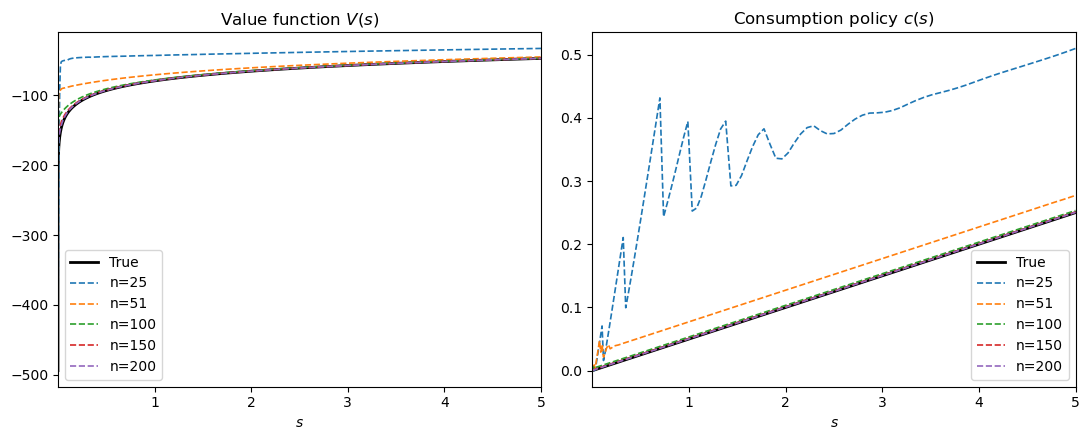

In [7]:
import matplotlib.pyplot as plt

# Grid sizes to compare (number of collocation nodes for linear solver)
n_list = [25, 51, 100, 150, 200]

# Common evaluation grid (same for all)
s_eval = s_fine
v_true = solver._v_true(s_eval, 0.95)
c_true = (1.0 - 0.95) * s_eval  # consumption = (1-beta)*s for log utility

results_by_n = []
t0_spline_total = time.perf_counter()
for n in n_list:
    print(f"Solving for n={n} spline nodes")
    model_n = CakeModel(beta=0.95, smin=1e-9, smax=5.0, n=n, basis="spli", s_fine=s_eval, tol=1e-6)
    t0_n = time.perf_counter()
    out = solver.solve_linear(model_n)
    print(f"  done in {time.perf_counter() - t0_n:.2f} s")
    c_n = out["s"] - out["sprime"]  # consumption policy on s_eval
    results_by_n.append({
        "n": n,
        "v": out["v"],
        "c": c_n,
        "v_true": out["v_true"],
        "max_value_err": float(np.max(np.abs(out["v"] - out["v_true"]))),
        "max_consumption_err": float(np.max(np.abs(c_n - c_true))),
        "iterations": out["iterations"],
    })
print(f"Total (splines): {time.perf_counter() - t0_spline_total:.2f} s")

# Summary table: accuracy vs n
accuracy_df = pd.DataFrame([
    {"n": r["n"], "max |V−V_true|": r["max_value_err"], "max |c−c_true|": r["max_consumption_err"], "iterations": r["iterations"]}
    for r in results_by_n
])
display(accuracy_df)

# Plots: value function and consumption policy for each n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.set_title("Value function $V(s)$")
ax1.plot(s_eval, v_true, "k-", lw=2, label="True")
for i, r in enumerate(results_by_n):
    ax1.plot(s_eval, r["v"], "--", lw=1.2, label=f"n={r['n']}")
ax1.set_xlabel("$s$")
ax1.legend()
ax1.set_xlim([s_eval[0], s_eval[-1]])

ax2.set_title("Consumption policy $c(s)$")
ax2.plot(s_eval, c_true, "k-", lw=2, label="True")
for i, r in enumerate(results_by_n):
    ax2.plot(s_eval, r["c"], "--", lw=1.2, label=f"n={r['n']}")
ax2.set_xlabel("$s$")
ax2.legend()
ax2.set_xlim([s_eval[0], s_eval[-1]])

plt.tight_layout()
plt.show()

## Accuracy vs number of grids (linear collocation, Chebyshev basis)

Same as above but using **Chebyshev** basis instead of splines. Solve linear value-function collocation for several $n$ and compare value function and consumption policy to the true solution on the same fine grid `s_fine`.

Solving for n=25 Chebyshev nodes
  linear it=25 err=3.0298e-02
  linear it=50 err=7.0823e-03
  linear it=75 err=1.9697e-03
  linear it=100 err=5.2829e-04
  linear it=125 err=1.4502e-04
  linear it=150 err=4.0124e-05
  linear it=175 err=1.1131e-05
  linear it=200 err=3.0859e-06
  linear it=222 err=9.9853e-07
  done in 0.60 s
Solving for n=51 Chebyshev nodes
  linear it=25 err=3.0275e-02
  linear it=50 err=7.2121e-03
  linear it=75 err=2.0997e-03
  linear it=100 err=6.1522e-04
  linear it=125 err=1.6948e-04
  linear it=150 err=4.6589e-05
  linear it=175 err=1.2926e-05
  linear it=200 err=3.5849e-06
  linear it=225 err=9.9422e-07
  done in 0.90 s
Solving for n=100 Chebyshev nodes
  linear it=25 err=3.0270e-02
  linear it=50 err=7.2642e-03
  linear it=75 err=2.1457e-03
  linear it=100 err=6.5212e-04
  linear it=125 err=1.9289e-04
  linear it=150 err=5.3592e-05
  linear it=175 err=1.4746e-05
  linear it=200 err=4.0949e-06
  linear it=225 err=1.1356e-06
  linear it=228 err=9.7372e-07
  done 

,n,max |V−V_true|,max |c−c_true|,iterations
0,25,354.585774,0.005727,222
1,51,327.467737,0.001373,225
2,100,301.874550,0.000364,228
3,150,286.465734,0.000170,229
4,200,275.533407,0.000096,230


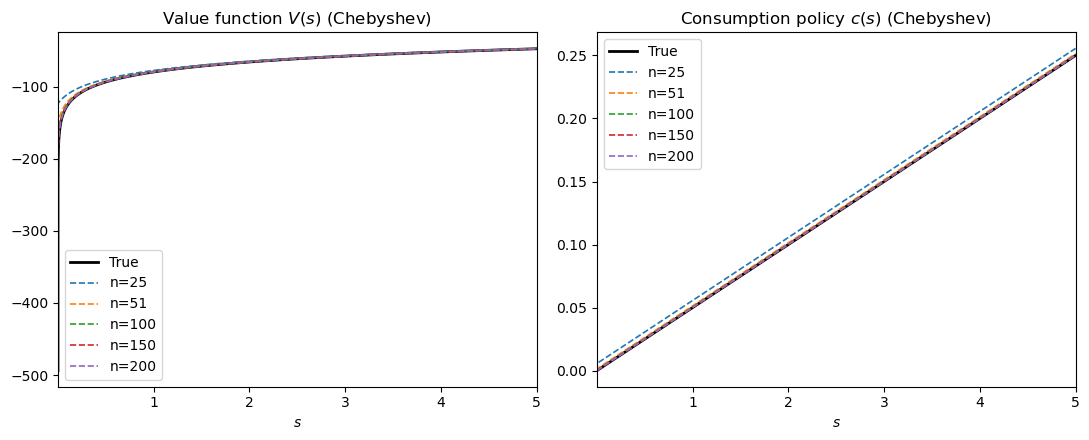

In [8]:
import matplotlib.pyplot as plt

# Grid sizes for Chebyshev linear collocation
n_list_cheb = [25, 51, 100, 150, 200]

s_eval_cheb = s_fine
v_true_cheb = solver._v_true(s_eval_cheb, 0.95)
c_true_cheb = (1.0 - 0.95) * s_eval_cheb

results_cheb = []
t0_cheb_total = time.perf_counter()
for n in n_list_cheb:
    print(f"Solving for n={n} Chebyshev nodes")
    model_n = CakeModel(beta=0.95, smin=1e-9, smax=5.0, n=n, basis="cheb", s_fine=s_eval_cheb, tol=1e-6)
    t0_n = time.perf_counter()
    out = solver.solve_linear(model_n)
    print(f"  done in {time.perf_counter() - t0_n:.2f} s")
    c_n = out["s"] - out["sprime"]
    results_cheb.append({
        "n": n,
        "v": out["v"],
        "c": c_n,
        "v_true": out["v_true"],
        "max_value_err": float(np.max(np.abs(out["v"] - out["v_true"]))),
        "max_consumption_err": float(np.max(np.abs(c_n - c_true_cheb))),
        "iterations": out["iterations"],
    })
print(f"Total (Chebyshev): {time.perf_counter() - t0_cheb_total:.2f} s")

accuracy_df_cheb = pd.DataFrame([
    {"n": r["n"], "max |V−V_true|": r["max_value_err"], "max |c−c_true|": r["max_consumption_err"], "iterations": r["iterations"]}
    for r in results_cheb
])
display(accuracy_df_cheb)

fig_cheb, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.set_title("Value function $V(s)$ (Chebyshev)")
ax1.plot(s_eval_cheb, v_true_cheb, "k-", lw=2, label="True")
for r in results_cheb:
    ax1.plot(s_eval_cheb, r["v"], "--", lw=1.2, label=f"n={r['n']}")
ax1.set_xlabel("$s$")
ax1.legend()
ax1.set_xlim([s_eval_cheb[0], s_eval_cheb[-1]])

ax2.set_title("Consumption policy $c(s)$ (Chebyshev)")
ax2.plot(s_eval_cheb, c_true_cheb, "k-", lw=2, label="True")
for r in results_cheb:
    ax2.plot(s_eval_cheb, r["c"], "--", lw=1.2, label=f"n={r['n']}")
ax2.set_xlabel("$s$")
ax2.legend()
ax2.set_xlim([s_eval_cheb[0], s_eval_cheb[-1]])
plt.tight_layout()
plt.show()

## Value and policy functions vs true solution

Three panels: value $V(s)$, savings policy $s'(s) = \beta s$, and consumption policy $c(s) = s - s'(s) = (1-\beta)s$. All compare linear (splines) and nonlinear (Chebyshev) to the closed-form solution.

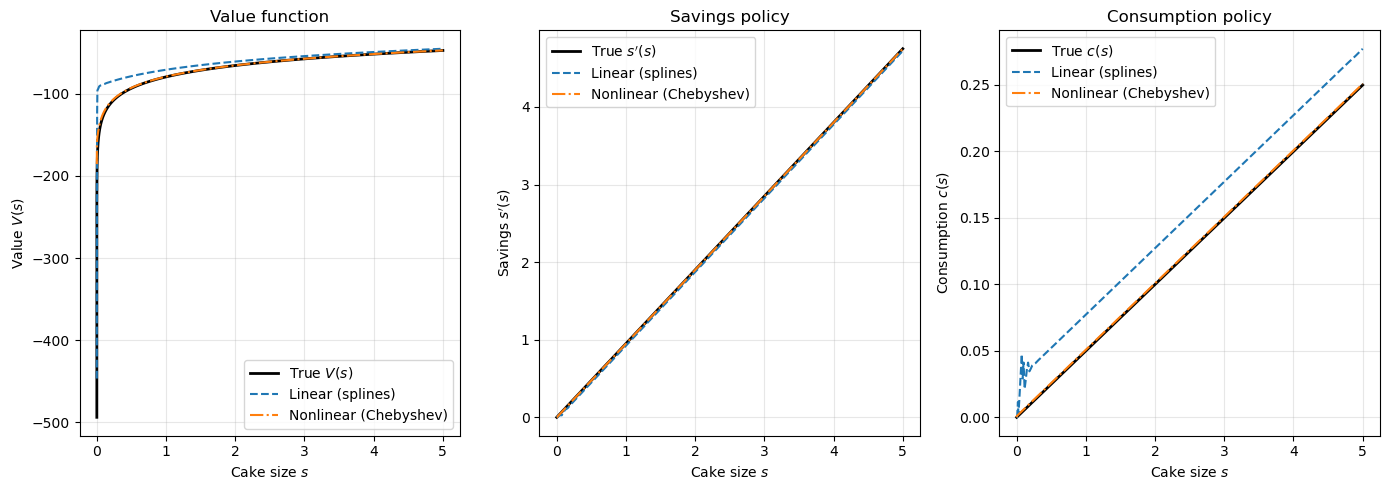

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
s = out_lin["s"]

# Value function
ax1.plot(s, out_lin["v_true"], "k-", lw=2, label="True $V(s)$")
ax1.plot(s, out_lin["v"], "C0--", lw=1.5, label="Linear (splines)")
ax1.plot(s, out_non["v"], "C1-.", lw=1.5, label="Nonlinear (Chebyshev)")
ax1.set_xlabel("Cake size $s$")
ax1.set_ylabel("Value $V(s)$")
ax1.set_title("Value function")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Policy function s'(s)
ax2.plot(s, out_lin["sprime_true"], "k-", lw=2, label="True $s'(s)$")
ax2.plot(s, out_lin["sprime"], "C0--", lw=1.5, label="Linear (splines)")
ax2.plot(s, out_non["sprime"], "C1-.", lw=1.5, label="Nonlinear (Chebyshev)")
ax2.set_xlabel("Cake size $s$")
ax2.set_ylabel("Savings $s'(s)$")
ax2.set_title("Savings policy")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Consumption policy c(s) = s - s'(s)
c_true = s - out_lin["sprime_true"]
c_lin = s - out_lin["sprime"]
c_non = s - out_non["sprime"]
ax3.plot(s, c_true, "k-", lw=2, label="True $c(s)$")
ax3.plot(s, c_lin, "C0--", lw=1.5, label="Linear (splines)")
ax3.plot(s, c_non, "C1-.", lw=1.5, label="Nonlinear (Chebyshev)")
ax3.set_xlabel("Cake size $s$")
ax3.set_ylabel("Consumption $c(s)$")
ax3.set_title("Consumption policy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
tex_dir = ROOT / "tex"
tex_dir.mkdir(exist_ok=True)
summary.to_csv(tex_dir / "problem3_summary.csv", index=False)
pd.DataFrame({
    "s": out_lin["s"],
    "sprime_linear": out_lin["sprime"],
    "sprime_nonlinear": out_non["sprime"],
    "sprime_true": out_lin["sprime_true"],
    "v_linear": out_lin["v"],
    "v_nonlinear": out_non["v"],
    "v_true": out_lin["v_true"],
}).to_csv(tex_dir / "problem3_profiles.csv", index=False)
print("Saved tables to", tex_dir)

Saved tables to /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/tex
